A friend of mine recently got a new espresso maker for their house and all of our discussions around getting the best shots out of it reminded me of [a rabbit hole I went down two years ago](/posts/engineering_a_cup_of_coffee_part-2/) exploring mass transfer in an espresso puck. It is time to revisit that earlier work and tie-off some unfinished threads.

In my previous post modelling mass transfer in espresso makers, I used a very particular set of initial conditions that worked well for solving the associated problem, and left it as a future exercise to generalize the work. That is the thread I am going to pick up and work through here: how do we extend those models to include different initial conditions?

## The Model Espresso System

I am revisiting the same model espresso system as before: a cylindrical puck of coffee grounds with hot water entering at the top, flowing through the bed, and exiting out the bottom, [@fig-domain]. As before, I am considering the case where the bed is initially filled with water at a lower pressure, the pre-infusion step, and at $t=0$ the pressure is ramped up to 6-9 bar and the shot is pulled. Over the course of the shot I assume the flowrate is constant.

::: {#fig-domain}
![](/posts/engineering_a_cup_of_coffee_part-2/fig-1-model.svg)

The problem domain, a cylindrical puck of coffee grounds with length $L$ and radius $R$.
:::

The whole point of making espresso is to extract coffee solubles from the ground coffee into the hot water. This is a classic mass transfer problem and is a special case of a standard chemical engineering unit operation called *leaching* ([@fig-mass-transfer]) -- typically when you see "extraction" in the literature it is referring to liquid-liquid extraction. Packed bed leaching is also analogous in many ways to adsorption/desorption operations, such as chromatography[@levan-2008], and drying using mol sieves. So there is a fair amount of literature on this for industrial scale operations[@schwartzberg-1987].

::: {#fig-mass-transfer}

```{dot}
//| fig-width: 5
//| fig-height: 4
digraph FlowDiagram {
    rankdir=TB;
    node [shape=box, style=rounded, fontname=helvetica, fontsize=10];
    edge [arrowsize=0.5];

    "Hot Water" -> "Liquid Phase";
    "Solid Phase" -> "Thin Film";
    "Thin Film" -> "Liquid Phase";
    "Liquid Phase" -> "Espresso Shot";

    { rank=same; "Solid Phase"; "Thin Film"; "Liquid Phase"; }
    
}
```

The mass transfer problem. Soluble components are transported from the solid phase, the coffee grounds, into the mobile liquid phase.
:::

### Liquid Phase

The standard approach to the liquid phase is to assume uniform plug flow (that the fluid velocity, $v$, is constant everywhere), and that the bed is uniform enough that radial diffusion can be neglected, resulting in a standard one-dimensional advection diffusion equation, [@eq-ad-diff].

$$ { {\partial c} \over {\partial t} } = \mathscr{D}_l { {\partial^2 c} \over {\partial z^2} } - v { {\partial c} \over {\partial z} } + \left({ 1 - \varepsilon } \over \varepsilon \right) a_v J_s $$ {#eq-ad-diff}

With the following notation:

+ $c$ - the concentartion of solubles in the liquid phase
+ $\mathscr{D}_l$ - the axial diffusivity
+ $v$ - the interstitial velocity of the fluid
+ $\varepsilon$ - the bed [porosity](https://en.wikipedia.org/wiki/Porosity)
+ $a_v$ - the [specific area](https://en.wikipedia.org/wiki/Surface-area-to-volume_ratio#Mathematical_examples) of the coffee grounds
+ $J_s$ - the flux of solubles into the liquid from the solid phase


### Solid Phase

The solid phase is treated as a packed bed of stationary spheres, each with an identical radius $b$. The mass transfer across the sphere is pure solid phase diffusion, [@eq-solid-diff], where it is assumed that the diffusion is perfectly spherically symmetric and in the radial direction $r$.

$$ { {\partial q} \over {\partial t} } = \mathscr{D}_s \left( { {\partial^2 q} \over {\partial r^2} }  + {2 \over r} { {\partial q} \over {\partial r} }  \right) $$ {#eq-solid-diff}

With the following notation:

+ $q$ - the concentration of solubles in the solid phase
+ $r$ - the radial direction on any individual sphere
+ $\mathscr{D}_s$ - the solid phase diffusivity

### Thin Film

Something needs to connect the two phases, transferring mass from the solid phase across into the liquid phase, and connecting [@eq-ad-diff] and [@eq-solid-diff]. This is conventionally done using the *thin film assumption*: we assume the concentration in the liquid immediately at the boundary a coffee ground is in equilibrium with a concentration $c_s(z,t) = \frac{q(b,z,t)}{K}$ and that the mass transfer across a thin film around the solid sphere is given by [@eq-thin-film]

$$ J_s = h \left( c_{s} -  c \right) = h \left( \frac{q(b,z,t)}{K} - c(z,t) \right)$$ {#eq-thin-film}

With the following notation:

+ $c_s$ - the concentration at the boundary of the solid sphere
+ $c$ - the concentration of the bulk liquid at that point
+ $K$ - the equilibrium constant, $K = q_s/c_s$
+ $h$ - the mass transfer coefficient

## The Anzelius Simplification

Much of what is published in the literature regarding espresso[^lit] adds some complexity to this model, for example adding multiple solid phases to represent different particle sizes, changing the equilibrium conditions be nonlinear, and adding details of the mass transfer through the microporous structure of the coffee grounds. This virtually forces one into using complex numerical solutions of the coupled PDEs.

[^lit]: @cameron-2020; @moroney-2015; @guerra-2024

If all you are interested in is the concentration exiting the portafilter, however, these numerical approaches can be a lot of unnecessary work. In my [previous post](/posts/engineering_a_cup_of_coffee_part-2/) I looked at various ways of approaching the original PDEs *without* having to resort to the full numerical treatment. This time I am looking at how changes in initial conditions, specifically how we treat the pre-infusion phase, changes the concentration profile at the exit of the portafilter.

I am going to start with a simplified model like the [Anzelius case](/posts/engineering_a_cup_of_coffee_part-2/#anzelius-integral-solution), where the PDE can be solved with Laplace transforms (and without having to tackle the [Bromwich integral](https://en.wikipedia.org/wiki/Inverse_Laplace_transform#Bromwich's_inverse_formula)). Assuming that the mass transfer can be approximated by a linear model with an average solid phase concentration $\bar{q}$ and that the velocity through the bed is large enough that axial dispersion can be neglected, the model simplifies to

$$ { {\partial c} \over {\partial t} } + v { {\partial c} \over {\partial z} } = \left({ 1 - \varepsilon } \over \varepsilon \right) a_v J_s $$ {#eq-anzelius-liq}

$$ { {\partial \bar{q}} \over {\partial t} } = - a_v J_s $$ {#eq-anzelius-solid}

with

$$ J_s = h_e \left( \frac{\bar{q}}{K} -  c \right) $$

The mass transfer coefficient is an *effective* mass transfer coefficient which combines the thin film mass transfer and solid phase diffusion into one parameter using a linear mass transfer resistance model. 

What I am aiming for with this model is the sweet spot between the complex, physics based, models that require detailed knowledge of the microscopic properties of coffee (and relatively large amounts of compute) and the fully empirical models of breakthrough curves[^simple] that are simple to calculate but require lots of empirical data every time. An Anzelius type model leads to a simple parameterization, where the parameters come from the physics, and can be obtained by semi-empirical correlations. The final model I've given here is not too dissimilar from that employed by @moroney-2019 (equations 21 and 22), though parameterized somewhat differently. In that case the model is solved using [MoL](https://en.wikipedia.org/wiki/Method_of_lines) instead of by Laplace transforms, as I do here, as the model is simultaneously estimating the flowrate from the given pressure and bed parameters whereas I assume it is a constant.

[^simple]: For example, those given by @hu-2019 where the breakthrough curves are approximated as either logistic, hyperbolic tangent, or double exponential functions with fitting parameters. These breakthrough curves are used by @waszkiewicz-2026 to analyze concentration profiles from a model espresso system. In a similar vein @levenspiel-2014 (pp 333-340) recommends approximating the breakthrough curve (for the equivalent heat transfer case) with the error function, with parameters coming from a linear heat transfer resistance model.

## System Parameters

Before we go too far in solving the PDE, it is worth pausing to think about all of the parameters that will be needed to use the model, where we will get them from, and how they will be stored.

There are some basic parameters we can get directly from the literature, such as the density and viscosity of water at espresso conditions -- I am assuming the water entering the portafilter and the coffee coming out have basically the same bulk density and kinematic viscosity.

In [1]:
#| echo: false
#| output: false
using CairoMakie, Latexify, DataFrames, CSV, Markdown

post_theme = merge(theme_latexfonts(), Theme(palette = (color = to_colormap(:seaborn_muted6),)));

In [2]:
#| output: false
using Unitful

# physical properties coffee
# assumed to be water at 90C and 10bar
ρ = 965.34u"kg/m^3"
μ = 0.282*0.001u"Pa*s"

0.00028199999999999997 Pa s

Similarly we can look to the literature[@cameron-2020 page 11] for some properties of the coffee itself -- the concentration of solubles in the coffee grounds as well as the saturation concentration in a cup of coffee, and the solid phase diffusivity of solubles through a coffee bean.

In [3]:
#| output: false
q_sat = 118.0u"kg/m^3"
c_sat = 212.4u"kg/m^3"
𝒟ₛ = 6.25e-10u"m^2/s"

6.25e-10 m^2 s^-1

### The Packed Bed

The packed bed of coffee grounds makes for a logical subunit to me, for storing information and managing the units. Since I am using [Unitful](https://juliaphysics.github.io/Unitful.jl/stable/) to manage unit consistency, I would like to also keep groups of like parameters in the same units, so I've written a small helper function to

1. convert all quantities of the same type to the same units, and 
2. promote the number type to the same type (e.g. all numbers to `Float64` or whatever.

In [4]:
#| output: false
consistency(quantities...; ustr) = 
  promote((uconvert(ustr, q) for q in quantities)...)

consistency (generic function with 1 method)

A `PackedBed`, in my mind, is the state of the portafilter right when it is inserted. It has some dimensions, a porosity, and some properties for the grounds: an effective spherical diameter, solid diffusivity, and initial concentration of coffee solubles. But no extraction has happened yet.

In [5]:
#| output: false
struct PackedBed{F,Q1,Q2,Q3}
    R::Q1 # bed radius
    L::Q1 # bed length
    ε::F  # bed porosity
    m::F  # bed porosity parameter (1-ε)/ε
    b::Q1 # particle size
    D::Q2 # solid phase diffusion
    q::Q3 # initial concentration
end

function PackedBed(;R,L,ε,b,D=𝒟ₛ,q=q_sat) 
    R, L, b = consistency(R,L,b; ustr=u"m")
    D = uconvert(u"m^2/s", D)
    q = uconvert(u"kg/m^3", q)
    @assert unit(ε) == NoUnits
    m = (1-ε)/ε
    return PackedBed(R,L,ε,m,b,D,q)
end

PackedBed

I can pull some parameters from literature sources, as I did before, for a model espresso puck. In the original post I used a particle size more representative of the fines, for this example I am using something closer to the mode of the particle size distribution of a typical espresso grind[@gagne-2020 page 46].

In [6]:
#| output: false
puck = PackedBed(
    ε = 1 - 0.8272,  # porosity
    b = 120u"μm",    # particle size
    R = 29.2u"mm",   # puck radius
    L = 18.7u"mm",   # puck length
    q = q_sat,       # solubles content in initial bed
    D = 𝒟ₛ           # solid phase diffusivity
    )

PackedBed{Float64, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}, Quantity{Float64, 𝐋^2 𝐓^-1, Unitful.FreeUnits{(m^2, s^-1), 𝐋^2 𝐓^-1, nothing}}, Quantity{Float64, 𝐌 𝐋^-3, Unitful.FreeUnits{(kg, m^-3), 𝐌 𝐋^-3, nothing}}}(0.0292 m, 0.0187 m, 0.17279999999999995, 4.787037037037039, 0.00012 m, 6.25e-10 m^2 s^-1, 118.0 kg m^-3)

### The Shot

The water coming into the espresso has only a few relevant parameters: the flowrate of water, density, and dynamic viscosity. I am assuming the incoming water has no coffee solubles in it, i.e. this model does not work for the case where you make espresso by running black coffee through your machine (weirdo). It is easier to initialize a given shot by giving the mass of water dispensed and the time it took.

In [7]:
#| output: false
struct EspressoWater
    Q # volumetric flowrate
    ρ # density
    ν # dynamic viscosity
end

function EspressoWater(;M, t, ρ=ρ, μ=μ)
    Q = upreferred((M/ρ)/t)
    ν = upreferred(μ/ρ)
    
    return EspressoWater(Q,ρ,ν)
end

EspressoWater

In [8]:
#| output: false
shot = EspressoWater(
    M = 40u"g",
    t = 20u"s"
    )

EspressoWater(2.071808896347401e-6 m^3 s^-1, 965.34 kg m^-3, 2.921250543849835e-7 m^2 s^-1)

### Equilibrium

If the bed is filled with hot water and simply left, it will achieve equilibrium with the coffee grounds. This represents the maximum concentration that the coffee can achieve. This can be calculated from a mass balance. Before the bed is wetted with water, all of the solubles are in the solid phase:

$$ m_i = \bar{q}_0 (1 - \varepsilon) V $$

After equilibrium the liquid phase has some concentration $c_{e}$ and the solid phase has some concentration $\bar{q}_{e}$

$$ m_f = c_{e} \varepsilon V + \bar{q}_{e} ( 1 - \varepsilon ) V $$

Since the system is at equilibrium $\bar{q}_{e} = K c_{e}$

$$ m_f = c_{e} V \left( \varepsilon + K ( 1 - \varepsilon ) \right) $$

As the bed has been filled with water, but nothing has flowed out yet, these two masses are equal

$$ \bar{q}_0 V (1 - \varepsilon) = c_e V \left( \varepsilon + K ( 1 - \varepsilon ) \right) $$

$$ c_e = { {1 - \varepsilon} \over {\varepsilon + K \left( 1 - \varepsilon \right)} } \bar{q}_0 $$

$$ c_e = \frac{m}{1 + Km} \bar{q}_0 $$

In [9]:
#| output: false
function equilibrium(K, m, q₀)
    cₑ = m*q₀/(1+K*m)
    qₑ = K*cₑ
    return cₑ, qₑ
end

equilibrium (generic function with 1 method)

### Pre-Infusion

The first step in making espresso is a lower pressure saturation of the bed with hot water before the pressure is ramped up and the shot is drawn. This is the pre-infusion step.

::: {#fig-extraction-steps}

```{dot}
//| fig-height: 2
//| fig-width: 5
digraph FlowDiagram {
    rankdir=LR;
    node [shape=box, style=rounded, fontname=helvetica, fontsize=10];
    edge [arrowsize=0.5];

    "Initial State" -> "Pre-Infusion" [label="0"];
    "Pre-Infusion" -> "Extraction" [label="1"];
}
```

The phases of extraction, (0) the bed starts dry with concentration $\bar{q}_0$ and the water enters with concentration $c_0 = 0 \frac{\mathrm{g}}{\mathrm{L}}$. After the pre-infusion (1) the bed is left with concentration $\bar{q}_1(z)$ and the liquid in the bed has concentration $c_1(z)$.
:::

The dynamics of what is going on inside is more complex than I can really tackle in this blog post. I am only going to look at the case where the bed, after the pre-infusion step, has a constant concentration $c_1$. For the mass balance to remain consistent, the solid phase is partially extracted with a concentration $\bar{q}_1 < \bar{q}_0$. This can be calculated assuming all mass starts in the solid phase.

$$
\bar{q}_0 \left( 1 - \varepsilon \right) V = c_1 \varepsilon V + \bar{q}_1 \left(1 - \varepsilon \right) V $$

$$ \bar{q}_1 = \bar{q}_0 - { \varepsilon \over \left( 1 - \varepsilon \right) } c_1 $$

$$ \bar{q}_1 = \bar{q}_0 - \frac{c_1}{m} $$

Which allows the user to specify some starting concentration $0 \lt c_1 \lt c_e$ to initialize the pre-infusion state of the espresso bed.

In [10]:
#| output: false
preinfusion(m, c₁, q₀) = q₀ - c₁/m

preinfusion (generic function with 1 method)

### The Extraction

Combining the hot water and the packed bed produces the `EspressoExtract`, and I think this step is where it is convenient to calculate the mass transfer coefficients and other parameters of the final system.

In [11]:
struct EspressoExtract
    pb::PackedBed
    wt::EspressoWater
    h
    a
    v
    c₁
    q₁
    cₑ
    qₑ
    K
end

The thin film mass transfer coefficient is typically estimated from correlations of the [Sherwood number](https://en.wikipedia.org/wiki/Sherwood_number) which is a function of the [Reynolds number](https://en.wikipedia.org/wiki/Reynolds_number) and [Schmidt number](https://en.wikipedia.org/wiki/Schmidt_number). In this case I am using the Wilson-Geankopolis correlation[^wg] for mass transfer in a packed bed with spherical packing. There are some big caveats here: I picked that correlation because it was convenient, but it was derived empirically from fairly long packed beds with uniform spherical packing and a fairly large porosity. An espresso puck is quite short for a packed bed, and the porosity is quite low, so this is probably only an order of magnitude estimate for $h$.

$$ Sh = \frac{1.09}{\varepsilon} \sqrt[3]{Re Sc} $$

[^wg]: @hottel-2008 page 5-77; @wilson-1966

In [12]:
#| output: false
Sh(ε,Re,Sc) = (1.09/ε)*∛(Re*Sc)

Sh (generic function with 1 method)

Most of the parameters needed to define the system are calculated from what is already known for the packed bed and shot parameters, and so initializing the `EspressoExtract` is fairly easy.

In [13]:
#| output: false
function EspressoExtract(pb,wt; 
                         c₁=zero(c_sat),
                         K=q_sat/c_sat)
    
    R, b, ε, m, Dₛ = pb.R, pb.b, pb.ε, pb.m, pb.D
    Q, ν = wt.Q, wt.ν
    
    # velocity and Reynolds number  #<1>
    A  = π*R^2                      #<1>
    vₛ = Q/A # superficial velocity #<1>
    v  = vₛ/ε                       #<1>
    Re = upreferred(vₛ*(2b)/ν)      #<1>
    @assert unit(Re) == NoUnits     #<1>

    # specfic area          #<2>
    a  = 3/b # for a sphere #<2>

    # estimating thin film mass transfer coefficient #<3>
    Dₗ = 5Dₛ                                         #<3>
    Sc = upreferred(ν/Dₗ)                            #<3>
    @assert unit(Sc) == NoUnits                      #<3>
    h = Sh(ε,Re,Sc)*Dₗ/(2b)                          #<3>

    # estimating solid phase diffusion equivalent h #<4>
    hₛ = (5K*Dₛ)/b                                  #<4>

    # linear mass transfer resistances #<5>
    hₑ = ( ((1-ε)*h)^-1 + hₛ^-1 )^-1   #<5>

    # calculating initial bed state                   #<6>
    @assert unit(K) == NoUnits                        #<6>
    c₁, q₀ = consistency(c₁, pb.q; ustr=unit(pb.q))   #<6>
    cₑ, qₑ = equilibrium(K, m, q₀)                    #<6>
    if c₁ < zero(cₑ)                                  #<6>
        c₁ = zero(cₑ)                                 #<6>
    end                                               #<6>

    if c₁ ≥ cₑ                                        #<6>
        c₁ = cₑ                                       #<6>
        q₁ = qₑ                                       #<6>
    else                                              #<6>
        q₁ = preinfusion(m, c₁, q₀)                   #<6>
    end                                               #<6>

    return EspressoExtract(pb,wt,hₑ,a,v,
                           c₁,q₁,cₑ,qₑ,K)
end

EspressoExtract

1. Calculate the interstitial velocity and superficial velocity, the Reynolds number is given in terms of the superficial velocity.
2. Calculate the specific area for the given particle size
3. Estimate the thin film mass transfer coefficient $h$ using the Wilson-Geankopolis correlation
4. Estimate the equivalent mass transfer coefficient for the solid phase diffusion
5. Estimate an overall effective mass transfer coefficient using a linear mass transfer resistance model $\frac{1}{h_e} = \frac{1}{h_s} + \frac{1}{1-\varepsilon}\frac{1}{h}$
6. Calculate the equilibrium state and the initial state of the bed, after pre-infusion but before extraction phase has begun. The concentration after pre-infusion is constrained to be less than the equilibrium concentration.

In [14]:
#| output: false
ext = EspressoExtract(puck,shot)

EspressoExtract(PackedBed{Float64, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}, Quantity{Float64, 𝐋^2 𝐓^-1, Unitful.FreeUnits{(m^2, s^-1), 𝐋^2 𝐓^-1, nothing}}, Quantity{Float64, 𝐌 𝐋^-3, Unitful.FreeUnits{(kg, m^-3), 𝐌 𝐋^-3, nothing}}}(0.0292 m, 0.0187 m, 0.17279999999999995, 4.787037037037039, 0.00012 m, 6.25e-10 m^2 s^-1, 118.0 kg m^-3), EspressoWater(2.071808896347401e-6 m^3 s^-1, 965.34 kg m^-3, 2.921250543849835e-7 m^2 s^-1), 1.3718875729903786e-5 m s^-1, 25000.0 m^-1, 0.004476003112601868 m s^-1, 0.0 kg m^-3, 118.0 kg m^-3, 154.3587292662356 kg m^-3, 85.75484959235311 kg m^-3, 0.5555555555555556)

## Rate Constants and System Dynamics

In my original post I simply sourced parameters from the literature and ended up with very fast dynamics. This is mostly due to some of the underlying assumptions: particles with very small Sauter mean diameters dominate the extraction, and I assumed the bed was made entirely of them. These are the fines. The rate of mass transfer is strongly impacted by the particle size and so the observed rates were extremely fast.

We can explore this directly with the linear mass transfer resistance model, and look at what the effective mass transfer coefficient is for different particle sizes. A larger mass transfer coefficient leads to a faster extraction. It is clear from [@fig-h-plot] that the mass transfer coefficients for very small particles, with radii <50μm, grows sharply as the diameter decreases. This means that not only is the extraction very fast in this region, but small differences in estimates of particle size will lead to large errors in estimated mass transfer rates.

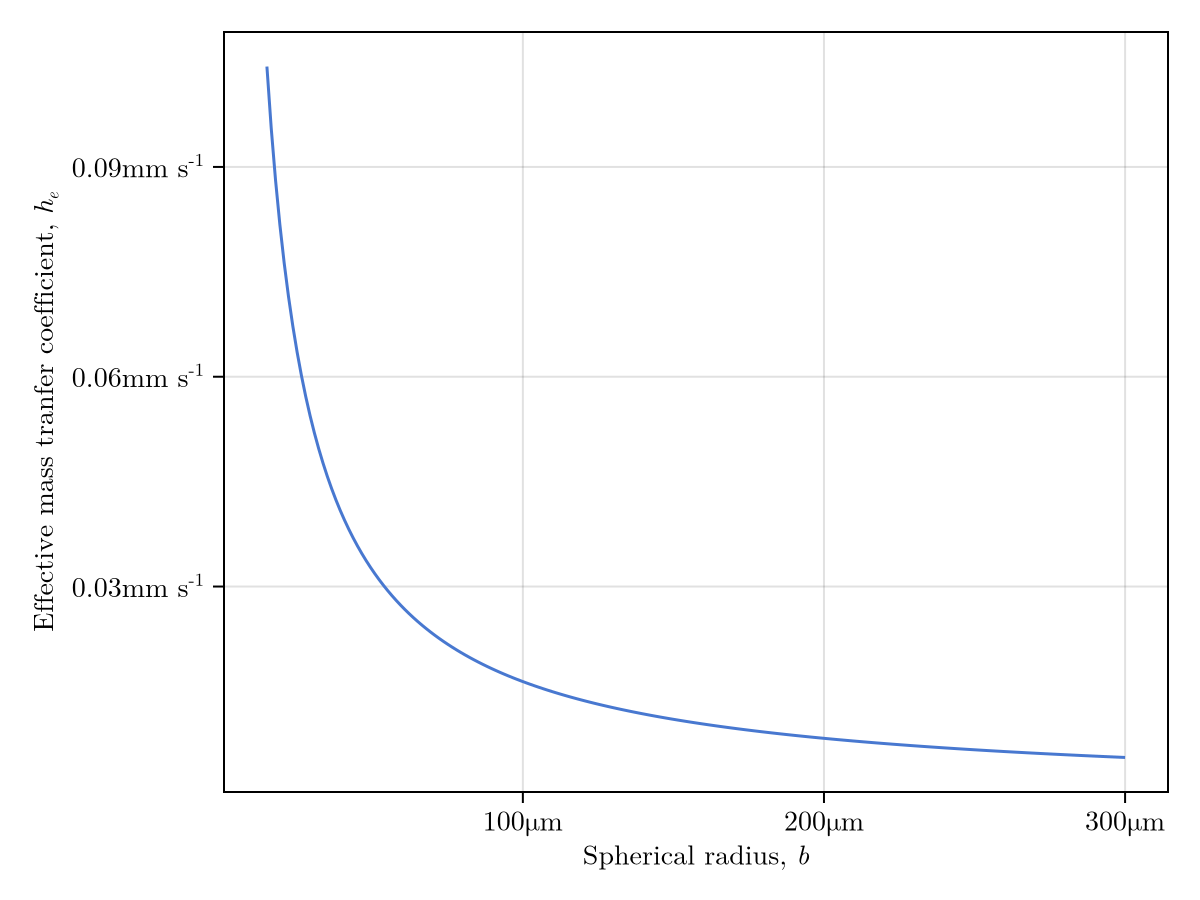

In [28]:
#| echo: false
#| label: fig-h-plot
#| fig-cap: "Effective mass transfer coefficient as a function of spherical radius, b. This mass transfer coefficient combines of thin film mass transfer and solid phase diffusion."

with_theme(post_theme) do

function h_e(ext, b)
    R, ε, Dₛ, Q, ν = ext.pb.R, ext.pb.ε, ext.pb.D, ext.wt.Q, ext.wt.ν
    K = ext.K
    # velocity and Reynolds number
    A  = π*R^2
    vₛ = Q/A # superficial velocity
    v  = vₛ/ε
    Re = upreferred(vₛ*(2b)/ν)
    @assert unit(Re) == NoUnits

    # specfic area
    a  = 3/b # for a sphere

    # estimating thin film mass transfer coefficient
    Dₗ = 5Dₛ
    Sc = upreferred(ν/Dₗ)
    @assert unit(Sc) == NoUnits
    h = Sh(ε,Re,Sc)*Dₗ/(2b)

    # estimating solid phase diffusion equivalent h
    hₛ = (5K*Dₛ)/b

    # linear mass transfer resistances
    hₑ = ( ((1-ε)*h)^-1 + hₛ^-1 )^-1

    return uconvert(u"m/s",hₑ)
end

bs = LinRange(15u"μm",300u"μm",200)
hs = [ h_e(ext,b) for b in bs ]

f1 = Figure()
ax1 = Axis(f1[1, 1],
    xlabel = L"Spherical radius, $b$",
    dim1_conversion = Makie.UnitfulConversion(u"μm"),
    ylabel = L"Effective mass tranfer coefficient, $h_e$",
    dim2_conversion = Makie.UnitfulConversion(u"mm/s")
)
lines!(ax1, bs, hs)

f1
end

In the region where I am modelling the extraction, in this post, the mass transfer coefficient is smaller and the slope is much flatter. So small errors around the mode of a typical expresso particle size distribution will have less of an effect on predicted mass transfer coefficients.

The complication we face is that the particle sizes that are relevant to the packed bed extraction are not the same particle sizes as what are measured coming out of a grinder. The coffee grounds absorb water and swell to some extent during the pre-infusion phase. We can't easily measure the actual, effective, particle sizes during extraction, which should lead us to be suspicious of this model for small particle sizes. Whatever estimate we have of the particle size when the puck is dry is likely too small, but by how much we do not know, but we do know the error in our estimate will be large since the slope of the mass transfer coefficient curve is quite large at these small diameters.

In practice this isn't really cause for despair, we can treat $h_e a_v$ as a single parameter -- that is the only place particle size appears in the PDE -- and fit it to observed extractions. The model really only has a few free parameters that define the extraction: $h_e a_v$, $K$, $\varepsilon$ and $q_0$, assuming the bed dimensions $L$, $R$, and the flowrate $Q$ can be measured. Getting good curves would require generating multiple shots of espresso across a range of appropriate variables -- grind size, how firmly the tamp is pressed down, etc. but also coffee bean types, brew temperatures, pressures -- and involve a fair amount of data analysis. Helpfully, after having drank all the espresso generated during the data acquisition phase, the data analysis will just fly by.

## Dimensionless Form

It is almost always good practice to put a PDE in dimensionless form before trying to solve it. I don't think there are any deep mathematical reasons for this, it is just simply that if you do it in a clever enough way a lot of the constants that define the physical system cancel out or can be grouped togethr and the resulting equation is much simpler. It also puts it in a form where you can just look things up in books: in my previous post I used models derived for heat regerators, a kind of heat storage device, not because the physics has anything to do with how an espresso maker works but because the equations in dimensionless form were the same.

Previously, I looked at the case where the bed and extract start at equilibirum and the moving front of hot water coming through the bed is what starts the extraction. This allowed me to use a change of variables to eliminate the time derivative of $c$. For this post I want to consider cases where the espresso starts away from equilibrium and so mass transfer begins instantly, before the moving front arrives.

With that in mind, let $\xi$ be a dimensionless distance defined to be:
$$
\xi = \frac{m h a_v}{v} z
$$

and let $\tau$ be a dimensionless time:
$$
\tau = \frac{h a_v}{K} t
$$

and let $u$ and $\upsilon$ be the dimensionless liquid phase and solid phase concentrations (respectively)
$$
u = \frac{K c}{\bar{q}_0}
$$

$$
\upsilon = \frac{\bar{q}}{\bar{q}_0}
$$

and finally let $\kappa = m K$. Making these all these substitutions, [@eq-anzelius-liq] and [@eq-anzelius-solid] become


$$
\boxed{
\frac{\partial u}{\partial \tau} + \kappa \frac{\partial u}{\partial \xi} = \kappa \left( \upsilon - u \right)
}
$$ {#eq-1}

$$
\boxed{
\frac{\partial \upsilon}{\partial \tau} = u - \upsilon
}
$$ {#eq-2}

## Initial Conditions
 In my original post I assumed that, during the pre-infusion phase, the bed rapidly equilibrates with the hot water. The bed fills with water, the grounds absorb some of that water and swell, and by the time the first drop is starting to form out of the portafilter the coffee grounds and water have reached equilibrium. The consequence of this is that right when the pressure ramps up and the shot is being pulled the whole system is in equilibrium with no net mass transfer between the solid and liquid phases.

$$ c(z,0) = c_{eq} $$

$$ q(z,0) = q_{eq} = K c_{eq} $$

$$ \frac{d q}{dt} |_{t=0} = 0$$

At the start of the shot proper, when $t=0$, a moving front of fresh hot water moves through the portafilter extracting coffee and leaving a bed of depleted grounds behind it.

This is convenient for solving the partial differential equations but one could object that it is not physically realistic. The bed has only *just* filled with water when the pre-infusion ends, so the actual concentration profiles are $c_1(z)$ and $\bar{q}_1(z)$. How do things change when we consider those initial condition?

Putting it in dimensionless form, suppose $u(\xi, 0) = u_1(\xi)$, and $\upsilon(\xi, 0) = \upsilon_1(\xi)$. Giving the list of initial and boundary conditions:

1. $u(\xi, 0) = u_1(\xi)$
2. $\upsilon(\xi, 0) = \upsilon_1(\xi)$
3. $u(0, \tau) = 0$

The system of equations can be easily solved using Laplace transforms, starting with the Laplace transform of [@eq-2]

$$ s \Upsilon - \upsilon_1(\xi) = U - \Upsilon $$

$$ \Upsilon = \frac{\upsilon_1(\xi)}{s+1} + \frac{U}{s+1} $$

then taking the Laplace transform of [@eq-1] and subtsituting for $\Upsilon$

$$ s U - u_1(\xi) + \kappa \frac{d U}{d \xi} = \kappa \left( \frac{\upsilon_1(\xi)}{s+1} + \frac{U}{s+1} - U \right) $$

which can be re-written

$$ \frac{d U}{d \xi} + \left( \frac{s}{\kappa} + \frac{s}{s+1} \right) U = \frac{\upsilon_1(\xi)}{s+1} + \frac{u_1(\xi)}{\kappa}$$

which is a linear first order ODE of the form 

$$f^{\prime} + P(x) f = Q(x)$$

and can be solved using integrating factors: 

$$f(x) = \frac{1}{\mu(x)} \left( \int \mu(x) Q(x) dx + C \right)$$

where $\mu(x)$ is the integrating factor and $C$ is a constant determined from the boundary conditions. In this case the integrating factor is 

$$\mu(\xi) = \exp\left( \left( \frac{s}{\kappa} + \frac{s}{s+1} \right) \xi \right)$$ 

giving

$$ U = \exp \left( -\left( \frac{s}{\kappa} + \frac{s}{s+1} \right) \xi \right) \left[ \int_0^\xi \exp \left( \left( \frac{s}{\kappa} + \frac{s}{s+1} \right) x \right) \left( \frac{\upsilon_1(x)}{s+1} + \frac{u_1(x)}{\kappa} \right) dx \right]$$ {#eq-U}

Here one has to make some choices. The particular form of $u_1(x)$ and $\upsilon_1(x)$ will govern whether or not the integral is achievable, and also whether or not the inverse Laplace transform is practical.

### Constant Initial Conditions
The obvious simple case is when $\upsilon_1(\xi) = \upsilon_1$ and $u_1(\xi) = u_1$, constants. This simplifies things enormously

$$ U = \frac{\kappa \upsilon_1 + u_1(s+1)}{s (s + 1 + \kappa)} \left[ 1 - \exp \left( -\left( \frac{s}{\kappa} + \frac{s}{s+1} \right) \xi \right)\right] $$

We can split this into two pieces for which we need to find the inverse Laplace transform, $F(s)$ and $G(s)$

$$ U = F(s) - \exp\left( -\frac{\xi}{\kappa} s \right) F(s)G(s) $$

with a final result in the form

$$ u(\tau) = f(\tau) - H \left( \tau - T \right) \int_0^{\tau - T} f(\tau - T - \lambda) g(\lambda) d\lambda $$ {#eq-generic-u}

where $T = \frac{\xi}{\kappa}$ is a time constant corresponding to when the moving front arrives at the location $\xi$, and $H(x)$ is the Heaviside step function (recalling that the inverse Laplace transform of $\exp(-as)F(s)$ is $H(\tau-a)f(\tau - a)$)

The first function, $F(s)$, is straight forward

$$ F(s) = \frac{\kappa \upsilon_1 + u_1(s+1)}{s (s + 1 + \kappa)} = \frac{\kappa \upsilon_1 + u_1}{1 + \kappa} \frac{1}{s} + \frac{\kappa (u_1 - \upsilon_1)}{1+\kappa} \frac{1}{s + 1 + \kappa} $$

$$
\boxed{
f(\tau) = \frac{\kappa \upsilon_1 + u_1}{1 + \kappa} + \frac{\kappa (u_1 - \upsilon_1)}{1+\kappa} \exp \left( - \left( 1 + \kappa \right) \tau \right) 
}
$$ {#eq-f}

The second function, $G(s) = \exp(-\frac{s}{s+1} \xi)$, requires some effort and [a good table of Laplace transforms](https://eqworld.ipmnet.ru/en/auxiliary/inttrans/laplace8.pdf) -- in this case I already know I am looking for something that includes the [modified Bessel function of the first kind](https://mathworld.wolfram.com/ModifiedBesselFunctionoftheFirstKind.html) because I know what the answer is for the case where $u_1 = \upsilon_1 = 1$. If you didn't already know that, this may be a very challenging function to invert without using a CAS (I *also* used a CAS to check my work!)

Firstly, I am going to note that

$$ \frac{s}{s+1} = 1 - \frac{1}{s+1}$$

therefore

$$ G(s) = \exp(-\frac{s}{s+1} \xi) = \exp \left( -\xi \right) \exp \left( \frac{\xi}{s+1} \right) $$

recall a more general property of Laplace transforms: 

$$\mathscr{L}^{-1} \{ G(s+1) \} = \exp(-\tau) \mathscr{L}^{-1} \{ G(s) \}$$

so we are interested in finding the inverse Laplace transform of $\exp \left( \frac{\xi}{s} \right)$

from the table of Laplace transforms:

$$ \mathscr{L}^{-1} \left\{ \frac{1}{\sqrt{a}} \left[ \exp \left(\frac{a}{s}\right) - 1 \right] \right\} = \frac{1}{\sqrt{\tau}} I_1 \left( 2 \sqrt{a\tau} \right) $$

Where $I_1(x)$ is the modified Bessel function of the first kind, of order one. That's close to what I want, so I can rewrite:

$$ \exp \left( \frac{\xi}{s} \right) = \sqrt{\xi} \left[ \frac{1}{\sqrt{\xi}} \left( \exp \left( \frac{\xi}{s} \right) -1 \right) \right] + 1 $$

For which the inverse is (note $\mathscr{L}^{-1} \{ 1 \} = \delta(\tau)$ the dirac delta function)

$$\mathscr{L}^{-1} \left\{ \exp \left( \frac{\xi}{s} \right) \right\} = \sqrt{\frac{\xi}{\tau}} I_1 \left( 2 \sqrt{\xi \tau} \right) + \delta(\tau) $$

::: {.callout-tip}
## An Alternative Approach

Another way of approaching this Laplace transform is to consider the following:

$$ \mathscr{L} \left\{ I_0 \left( 2 \sqrt{a\tau} \right) \right\} = \frac{1}{s} \exp \left( \frac{a}{s} \right) $$

$$ \mathscr{L} \left\{ \frac{d I_0 \left( 2 \sqrt{a\tau} \right)}{dt} \right\} = s \frac{1}{s} \exp \left( \frac{a}{s} \right) - I_0(0) $$

$$ \mathscr{L} \left\{ \sqrt{\frac{a}{\tau}} I_1 \left( 2 \sqrt{a\tau} \right) \right\}  = \exp \left( \frac{a}{s} \right) - 1 $$

$$ \mathscr{L} \left\{ \sqrt{\frac{a}{\tau}} I_1 \left( 2 \sqrt{a\tau} \right) + \delta(\tau) \right\}  = \exp \left( \frac{a}{s} \right) $$
:::

finally giving

$$ g(\tau) = \exp\left(- \left( \xi + \tau \right) \right) \left[ \sqrt{\frac{\xi}{\tau}} I_1 \left( 2 \sqrt{\xi \tau} \right) + \delta(\tau) \right] $$ {#eq-g}

Substituting [@eq-g] back into [@eq-generic-u] we get

$$
u(\xi, \tau) = f(\tau) - H(\tau - T) \biggl[ \exp(-\xi) f(\tau - T) +$${#eq-u-const-u1}
$$\int_0^{\tau - T} f(\tau - T - \lambda) \exp \left( - \left(\xi + \lambda\right) \right) \sqrt{\frac{\xi}{\lambda}} I_1 \left( 2\sqrt{\xi \lambda} \right) d\lambda \biggr] 
$$ 

We can recover the original Anzelius solution by letting $u_1 = \upsilon_1 = 1$^[at equilibrium $u_1 = \upsilon_1$ so this equates to simply scaling by some constant], giving $f(\tau) = 1$, substituting into [@eq-u-const-u1]

$$ u(\xi, \tau) = 1 - H(\tau - T) \left[ \exp(-\xi) + \int_0^{\tau - T} \exp \left( - \left(\xi + \lambda\right) \right) \sqrt{\frac{\xi}{\lambda}} I_1 \left( 2\sqrt{\xi \lambda} \right) d\lambda \right] $$

The integral can be tackled using integration by parts (using $\frac{d}{dx}I_0(x) = I_1(x)$) to give

$$ u(\xi, \tau) = 1 - H(\tau - T) \exp(-\xi) \left[ 1 + \left[\exp \left( -\lambda \right) I_0 \left( 2\sqrt{\xi \lambda} \right) \right]_{0}^{\tau - T} + \int_0^{\tau - T} \exp \left( - \lambda \right) I_0 \left( 2\sqrt{\xi \lambda} \right) d\lambda \right] $$

$$ = 1 - H(\tau - T) \exp(-\xi) \left[ \exp \left( -\tau + T \right) I_0 \left( 2\sqrt{\xi (\tau - T)} \right) + \int_0^{\tau - T} \exp \left( - \lambda \right) I_0 \left( 2\sqrt{\xi \lambda} \right) d\lambda \right] $$

making the substitution $u^{\prime} = 1-u$ and $\tau^{\prime} = \tau - T$, then for $\tau^{\prime} > 0$

$$
u^{\prime} = \exp \left( -(\tau^\prime + \xi) \right) I_0 \left( 2\sqrt{\tau^{\prime} \xi } \right) + \int_0^{\tau^{\prime}} \exp \left( - (\lambda + \xi) \right) I_0 \left( 2\sqrt{\xi \lambda} \right) d\lambda
$$

which is the [original Anzelius solution](/posts/engineering_a_cup_of_coffee_part-2/#anzelius-integral-solution).

### Polynomial Initial Conditions

Another convenient choice for initial conditions is that $\upsilon_1$ and $u_1$ are polynomials of order $n$, i.e. $\upsilon_1(\xi)=\sum_{k=0}^n a_i \xi^k$ and $u_1(\xi)=\sum_{k=0}^n b_i \xi^k$. The integral in [@eq-U] can be eliminated through repeated application of integration by parts: generally for some order n polynomial $p(x)$

$$
\int_0^\xi e^{\alpha x}p(x) dx =
\left[
e^{\alpha x}
\sum_{j=0}^{n} \frac{(-1)^j}{\alpha^{j+1}} p^{(j)}(x)
\right]_{x=0}^{x=\xi} $$
$$ = \exp\left(\alpha \xi \right) \sum_{j=0}^{n} \frac{(-1)^j}{\alpha^{j+1}} p^{(j)}(\xi) - \sum_{j=0}^{n} \frac{(-1)^j}{\alpha^{j+1}} p^{(j)}(0)
$$

plugging that into [@eq-U]

$$ U = \frac{1}{s+1} \sum_{j=0}^{n} (-1)^j \upsilon_1^{(j)}(\xi) \left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} $$
$$ - \frac{1}{s+1} \exp \left( -\left( \frac{s}{\kappa} + \frac{s}{s+1} \right) \xi \right) \sum_{j=0}^{n} (-1)^j \upsilon_1^{(j)}(0) \left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} $$
$$ + \frac{1}{\kappa} \sum_{j=0}^{n} (-1)^j u_1^{(j)}(\xi) \left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} $$
$$ - \frac{1}{\kappa} \exp \left( -\left( \frac{s}{\kappa} + \frac{s}{s+1} \right) \xi \right) \sum_{j=0}^{n} (-1)^j u_1^{(j)}(0) \left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} $$

The result will be of the form

$$ 
u(\xi,\tau) = f(\xi,\tau) - H(\tau - T) \biggl[ \exp(-\xi) g(\xi, \tau - T) + $$
$$\int_0^{\tau-T} g(\xi, \tau - T -\lambda) \exp\left( - (\xi + \tau) \right) \sqrt{\frac{\xi}{\lambda}} I_1 \left( 2 \sqrt{\xi \lambda} \right) d\lambda \biggr]
$$

where

$$
f(\xi,\tau) = \mathscr{L}^{-1} \left\{  \sum_{j=0}^{n} (-1)^j \left( \frac{ \upsilon_1^{(j)}(\xi)}{s+1} + \frac{( u_1^{(j)}(\xi)}{\kappa}\right) \left( \frac{\kappa (s+1)}{s(s+1+\kappa)} \right)^{j+1} \right\}
$$
$$
= \sum_{j=0}^n (-1)^j \upsilon_1^{(j)}(\xi) \sum_{i=0}^{j+1} \frac{\tau^{i-1}}{\left(i-1\right)!} \left( A_{ij} + B_{ij} \exp\left( - (1+\kappa) \tau\right) \right) +$$
$$
(-1)^j \frac{u_1^{(j)}(\xi)}{\kappa} \sum_{i=0}^{j+1} \frac{\tau^{i-1}}{\left(i-1\right)!} \left( C_{ij} + D_{ij} \exp\left( - (1+\kappa) \tau\right) \right)
$$

and
$$
g(\xi,\tau) = \mathscr{L}^{-1} \left\{ \sum_{j=0}^{n} (-1)^j \left( \frac{\upsilon_1^{(j)}(0)}{s+1} +\frac{u_1^{(j)}(0)}{\kappa} \right) \left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} \right\}
$$
$$
= \sum_{j=0}^n (-1)^j \upsilon_1^{(j)}(0) \left( 1 + \sum_{k=1}^{j+1} \frac{\tau^{i-1}}{\left(i-1\right)!} \left( A_{ij} + B_{ij} \exp\left( - (1+\kappa) \tau\right) \right) \right) +$$
$$
(-1)^j \frac{u_1^{(j)}(0)}{\kappa} \left( 1 + \sum_{k=1}^{j+1} \frac{\tau^{i-1}}{\left(i-1\right)!} \left( C_{ij} + D_{ij} \exp\left( - (1+\kappa) \tau\right) \right) \right)
$$

with the $A_{ij}$s, $B_{ij}$s, $C_{ij}$s, and $D_{ij}$s come from the partial fraction decompositions

$$
\frac{1}{s+1}\left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} = \sum_{i=1}^{j+1} \frac{A_{ij}}{s^i} + \frac{B_{ij}}{\left( s+1+\kappa\right)^i}
$$
and
$$
\left(\frac{\kappa (s+1)}{s (s+1+\kappa)} \right)^{j+1} = \sum_{i=1}^{j+1} \frac{C_{ij}}{s^i} + \frac{D_{ij}}{\left( s+1+\kappa\right)^i}
$$

respectively.

Working out the constants for the partial fraction decomposition will get pretty gnarly pretty quickly, depending on the order of the polynomial, but it is something easily handed off to a CAS to do. Probably the most useful approach would be simple linear or cubic interpolations of the concentration profiles, the higher order terms fall off pretty quickly (like $\frac{1}{n!}$) and are not very important to the final model.

For a quick check, $\upsilon_1$ and $u_1$ as constants (i.e. $n=0$) can be substituted into the expressions above to recover the case already derived for constant initial conditions.

## Properties and Dynamics

Let us take a moment and consider what the solution for constant initial conditions, [@eq-u-const-u1] , is telling us. For starters, it has recovered the equilibrium condition: when dimensionless time $\tau \to \infty$,  the dimensionless concentration (before the moving front arrives) $f(\tau) \to \frac{\kappa \upsilon_1 + u_1}{1 + \kappa} = u_e$, which makes sense. If we imagine ourselves to be at some point extremely distant from the origin, the bed immediately around us starts, at $\tau = 0$, to relax towards the equilibrium state. Since the bed is identical everywhere in the vicinity, the moving fluid does not change anything. It is equivalent to a bed saturated with water that is stagnant and relaxing towards equilibrium.

Then, once the moving front arrives, there is a sudden step from $f(T)$ to $f(T) - \exp(-\xi)u_1$. This is not a new result, it is present also in the original Anzelius solution, and is not a numerical artifact or error, it is a consequence of the assumptions made when solving the original PDE. In particular, that the system:

1. has no axial diffusion, and
2. the moving front is a square wave

This is the ghost of our simplifying assumptions and only becomes apparent at low values of $\xi$. We can reason about this a little differently if we think about $\xi$ as the ratio of two characteristic times for the system:

$$ \xi = {\textrm{time for fresh solvent to arrive at z} \over \textrm{time for new extract to dissolve} } $$

If it takes much longer for fresh solvent to arrive at the given point than it takes for new extract to dissolve out of the solid phase, then this discontinuitiy gets smoothed out. Otherwise we see the solvent front peeking through. In the literature for similar packed bed systems, in industrial applications, the beds are typically much longer than they are wide and it is an implicit assumption that the bed is not "too short", for this exact reason (the assumptions underlying the model breakdown). For the case of an espresso puck, unfortunately, the bed is quite short and so the system is on the edge of generating unphysical results. Especially for large particle sizes where the rate of extraction is small relative to the flowrate of water.

The sharp front in regions of small $\xi$ also presents numerical difficulties if, instead of finding the solution with Laplace transforms or the like, we were using numerical techniques like [MoL](https://en.wikipedia.org/wiki/Method_of_lines). This is because the spatial discretization adds an effective diffusivity that is a numerical artifact. By making the grid suitably small this effect can be shrunk, but it never really goes away. This results in a solution that looks more physically realistic than it should, given the assumptions.

::: {.callout-note}
Note this only applies when $u_1>0$, in the special case where $u_1=0$ the jump goes away and the transition is smooth.
:::

I think it is worth pausing a moment to mention that one other assumption made during model development implicitly assumes the bed is not too short: simple plug flow. Flow through porous media is well approximated as plug flow, when observed far from the origin. The velocity gradients seen in, for example, laminar pipeflow, get flattened out when the flow transitions to a porous media but there is a transition zone where this assumption doesn't hold very well.

## Concentration Profiles

I don't have a compelling polynomial model for the initial conditions. I worked out the polynomial case more for completeness than anything. Instead I am going to use the initial condition that I mentioned in passing, but didn't examine too deeply, in my previous post: $u_1 =0$ and $\upsilon_1 = 1$. This is equivalent to a bed that starts filled with hot water but in which there has been no mass transfer at all. In some sense this situation and the one for the original Anzelius case are the bracketing cases.

[Much like previously](/posts/engineering_a_cup_of_coffee_part-2/#integration-by-gauss-kronold), I am going to calculate the convolution using Gaussian quadrature, and make use of the exponentially scaled Bessel function.

In [16]:
#| output: false
using Bessels: besseli1x
using QuadGK: quadgk

The first step is to implement the function $f(\tau)$ from [@eq-f]

In [17]:
#| output: false
f(τ; κ, u₁, υ₁) =
  (κ*υ₁ + u₁ + κ*(u₁-υ₁)*exp(-(1+κ)*τ))/(1+κ)

f (generic function with 1 method)

Then the integrand from the integral term in [@eq-u-const-u1], making the substitution

$$
\exp(-(\xi - \lambda)) = \exp\left(- \left(\sqrt{\xi} + \sqrt{\lambda} \right)^2 \right) \exp\left( -\sqrt{4\xi\lambda} \right)
$$

and noting the definition of the exponentially scaled bessel function

$$
\mathrm{besseli1x}(x) = \exp(-x) I_1(x)
$$

In [18]:
#| output: false
fI(λ; τ, ξ, κ, u₁, υ₁) = 
  f(τ-λ; κ=κ, u₁=u₁, υ₁=υ₁)*
  √(ξ/λ)*exp(-(√(ξ)-√(λ))^2)*besseli1x(√(4ξ*λ))

fI (generic function with 1 method)

Finally I package the result, with a final check to make sure $u \ge 0$. Because of numerical error in the calculation of the integral (and other terms) it is possible for $u < 0$ to some slight degree, but that is unphysical and should be discarded.

In [19]:
#| output: false
function u(ξ,τ; κ, u₁, υ₁)
    T = ξ/κ
    if τ ≤ T
        u = f(τ, κ=κ, u₁=u₁, υ₁=υ₁)
    else
        ∫fIdλ, err = quadgk( 
            (x)-> fI(x; τ=(τ-T), ξ=ξ, κ=κ, u₁=u₁, υ₁=υ₁),0, τ-T)
        u = f(τ, κ=κ, u₁=u₁, υ₁=υ₁) - 
            ( exp(-ξ)*f(τ-T; κ=κ, u₁=u₁, υ₁=υ₁) + ∫fIdλ )
    end
    return max(zero(u),u)
end

u (generic function with 1 method)

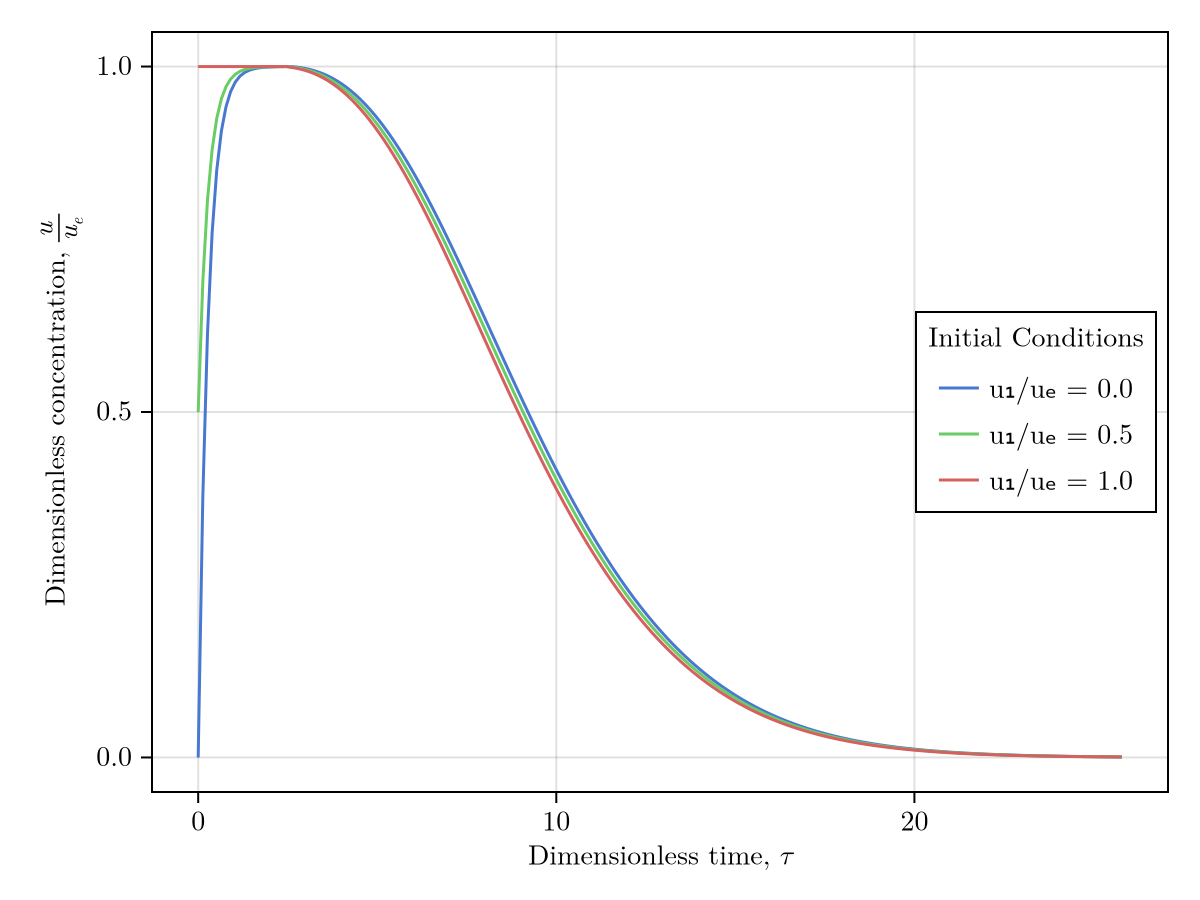

In [29]:
#| echo: false
#| label: fig-anz-int
#| fig-cap: "The dimensionless concentration *u* as a function of dimensionless time *τ* for various initial conditions. Note the graph has been scaled to the equilibrium concentration."
with_theme(post_theme) do

κ  = ext.K*ext.pb.m
ξ  = (ext.pb.m*ext.h*ext.a*ext.pb.L)/ext.v
T  = ξ/κ
ε  = ext.pb.ε
uₑ = ext.K*(1-ε)/(ε + ext.K*(1-ε))
    
τs = LinRange(0,10,200).*T

    
@inline u_max(;κ, u₁) = u(ξ, ξ/κ; κ=κ, u₁=u₁, υ₁=(1-u₁/κ))
@inline u_plt(ξ, κ, u₁, t) = u(ξ, t; κ=κ, u₁=u₁, υ₁=(1-u₁/κ))/
                             u_max(κ=κ, u₁=u₁)

f2 = Figure()
ax2 = Axis(f2[1, 1],
    xlabel = L"Dimensionless time, $\tau$",
    ylabel = L"Dimensionless concentration, $\frac{u}{u_{e}}$",
)

for u₁ in [0.0,0.5,1.0].*uₑ
    us = [u_plt(ξ,κ,u₁,τ) for τ in τs]
    lbl = "u₁/uₑ = $(round(u₁/uₑ; digits=1))"   
    lines!(ax2, τs, us, label=lbl)
end

axislegend(L"\textrm{Initial Conditions}", position = :rc)
f2
end


Examining [@fig-anz-int] gives some justification for my earlier decision to assume the bed was already at equilibrium: The bed equilibrates very rapidly and after a few seconds the differences in initial conditions are almost indistinguishable.

Turning this into a function to calculate the concentration given an `EspressoExtract` is quite straightforward, though it suggests that pre-calculating some groups and adding them to the struct could be a worthwhile enterprise.

In [21]:
#| output: false
function concentration(e::EspressoExtract, z, t)
    h, a, m, v, K = e.h, e.a, e.pb.m, e.v, e.K
    c₁, q₁, q₀ = e.c₁, e.q₁, e.pb.q
    ξ  = m*h*a*z/v
    τ  = h*a*t/K
    κ  = K*m
    u₁ = K*c₁/q₀
    υ₁ = q₁/q₀
    c  = (q₀/K)*u(ξ,τ;κ=κ,u₁=u₁,υ₁=υ₁)
    return c
end

concentration (generic function with 1 method)

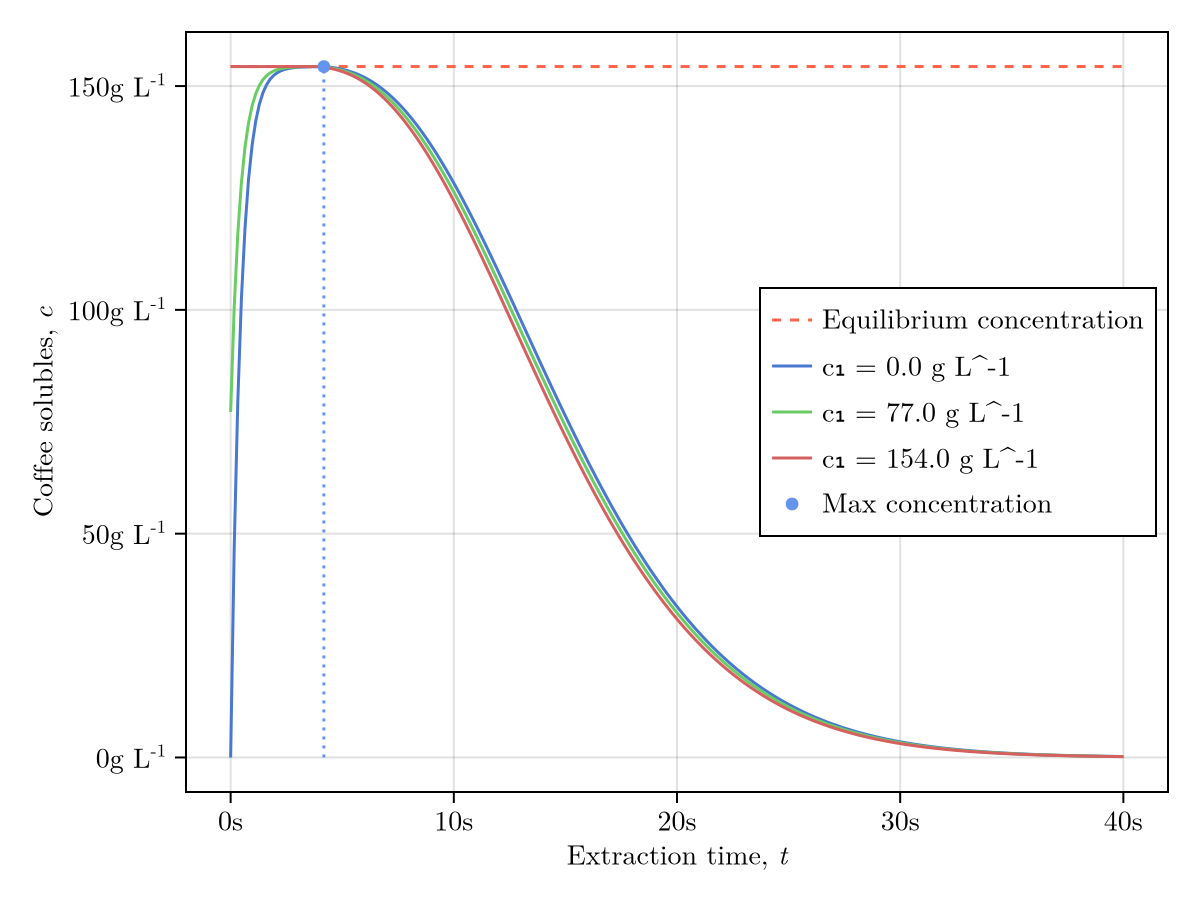

In [30]:
#| echo: false
#| label: fig-conc-plot
#| fig-cap: "The concentration at the exit of the portafilter for the example extraction, at a few initial conditions. The equilibrium concentration for the extraction is given for reference. The extraction rapidly achieves equilibrium before the bed is exhausted in later stages of the extraction."

with_theme(post_theme) do

ts = range(0u"s";stop=40u"s",length=250)
T  = ext.pb.L/ext.v
L  = ext.pb.L

f3 = Figure()
ax3 = Axis(f3[1, 1],
    xlabel = L"Extraction time, $t$",
    dim1_conversion = Makie.UnitfulConversion(u"s"),
    ylabel = L"Coffee solubles, $c$",
    dim2_conversion = Makie.UnitfulConversion(u"g/L")
)

lines!(ax3, [ts[1], ts[end]], [ext.cₑ, ext.cₑ],
       label="Equilibrium concentration",
       color=:tomato, linestyle=:dash)
for c in [0, 0.5, 1.0].*ext.cₑ
    e  = EspressoExtract(puck,shot; c₁=c)
    cs = [concentration(e,L,t) for t in ts]
    lines!(ax3, ts, cs,
           label="c₁ = $(round(u"g/L",c))",
           linestyle=:solid)
end

scatter!(ax3, [T], [concentration(ext,ext.pb.L,T)],
         label="Max concentration",
         color=:cornflowerblue)
lines!(ax3, [T, T], [0u"g/L", concentration(ext,ext.pb.L,T)], 
       color=:cornflowerblue, linestyle=:dot)  

axislegend(position = :rc)
f3

end

## Real Data

One thing that I didn't do in my previous post was compare my models to actual experimental data. This was pure laziness on my part -- that post was already very long. This time around I pulled some data from @moroney-2019 (Figure 6) for comparison. Note, these aren't really espresso beds. The experimental set-up is similar to an espresso maker in all meaningful respects: a cylindrical packed bed of coffee through which a hot water is passed at a stable pressure. But the grind size is closer to what you would expect for pour over.

What I want to show is that the concentration profile I have derived here can be fit to the observed results -- not necessarily that I can predict the exact performance (there are a lot of model parameters that need to be specified that aren't all available). This is a straightforward optimization problem: find the set of parameters that minimize the [least squares error](https://en.wikipedia.org/wiki/Least_squares). In this case I am fitting $\frac{c}{c_{max}}$ instead of the concentration directly.

::: {.callout-note}
The reason I don't use a gradient based optimization method here is simply because `Bessels.jl`, at the time of writing, does not support the standard automatic differentiation libraries in julia, and I cannot be bothered to figure out my own gradient function.
:::

In [23]:
#| output: false
using Optim

In [24]:
#| output: false
function fit_normalized_concentration(df, p0)
    function L2(params)
        τ₀, ξ, κ = params
        u_max = u(ξ, ξ/κ; κ=κ, u₁=0.0, υ₁=1.0)
        model = [u(ξ, τ₀*t; κ=κ, u₁=0.0, υ₁=1.0)/u_max
                 for t in df.time]
        return sum( (model .- df.normalized_c).^2 )
    end
    
    lower = zeros(3)
    upper = [Inf, Inf, Inf]
    return optimize(L2, lower, upper, p0,
                    Fminbox( NelderMead() ))
end

fit_normalized_concentration (generic function with 1 method)

In [25]:
#| echo: false
#| output: false
# Moroney et al. 2019
# Fig 6 (a) fine grained
# https://doi.org/10.1371/journal.pone.0219906.g006
moroney_2019_a = CSV.read(IOBuffer("""
time, concentration
5.14549901927743, 212.49367363169688
12.343810111656502, 150.58564095148574
18.846194789087264, 76.4767551153206
24.683216949834218, 43.48926324922272
33.28555462819827, 27.221459041283993
42.58071052846678, 17.73190658665311
54.288944973442966, 11.405538283565846
65.99821548276711, 6.886703781360666
78.39797306921281, 5.079169980478554
90.79850770391946, 4.627286530258033
102.50959132585251, 3.2716361795964986
114.90960792838519, 1.9159858289349359
127.31014256309189, 1.464102378714415
139.71093621388553, 1.464102378714415
152.45541930671803, 0.10845202805285226
"""), DataFrame; delim=", ", types=[Float64, Float64], header=true);

moroney_2019_a.normalized_c = moroney_2019_a.concentration ./ 
                    maximum(moroney_2019_a.concentration);

In [26]:
#| echo: false
#| output: false
# Moroney et al. 2019
# Fig 6 (c) coarse grained
# https://doi.org/10.1371/journal.pone.0219906.g006
moroney_2019_c = CSV.read(IOBuffer("""
time, concentration
4.123711340206185, 82.84671532846713
10.309278350515463, 80.47445255474452
16.494845360824733, 62.22627737226276
22.680412371134025, 44.525547445255455
30.584192439862534, 32.84671532846713
38.48797250859106, 24.635036496350324
49.48453608247422, 19.708029197080265
62.19931271477664, 13.138686131386862
74.91408934707903, 10.766423357664195
86.59793814432989, 7.846715328467127
100.34364261168385, 6.93430656934305
113.74570446735395, 5.839416058394136
126.46048109965638, 4.744525547445221
138.1443298969072, 4.197080291970792
150.8591065292096, 3.649635036496335
163.23024054982818, 3.649635036496335
177.31958762886597, 2.55474452554742
190.7216494845361, 2.55474452554742
205.84192439862545, 2.737226277372258
219.24398625429552, 2.189781021897801
232.30240549828176, 2.3722627737226105
"""), DataFrame; delim=", ", types=[Float64, Float64], header=true);

moroney_2019_c.normalized_c = moroney_2019_c.concentration ./ 
                    maximum(moroney_2019_c.concentration);

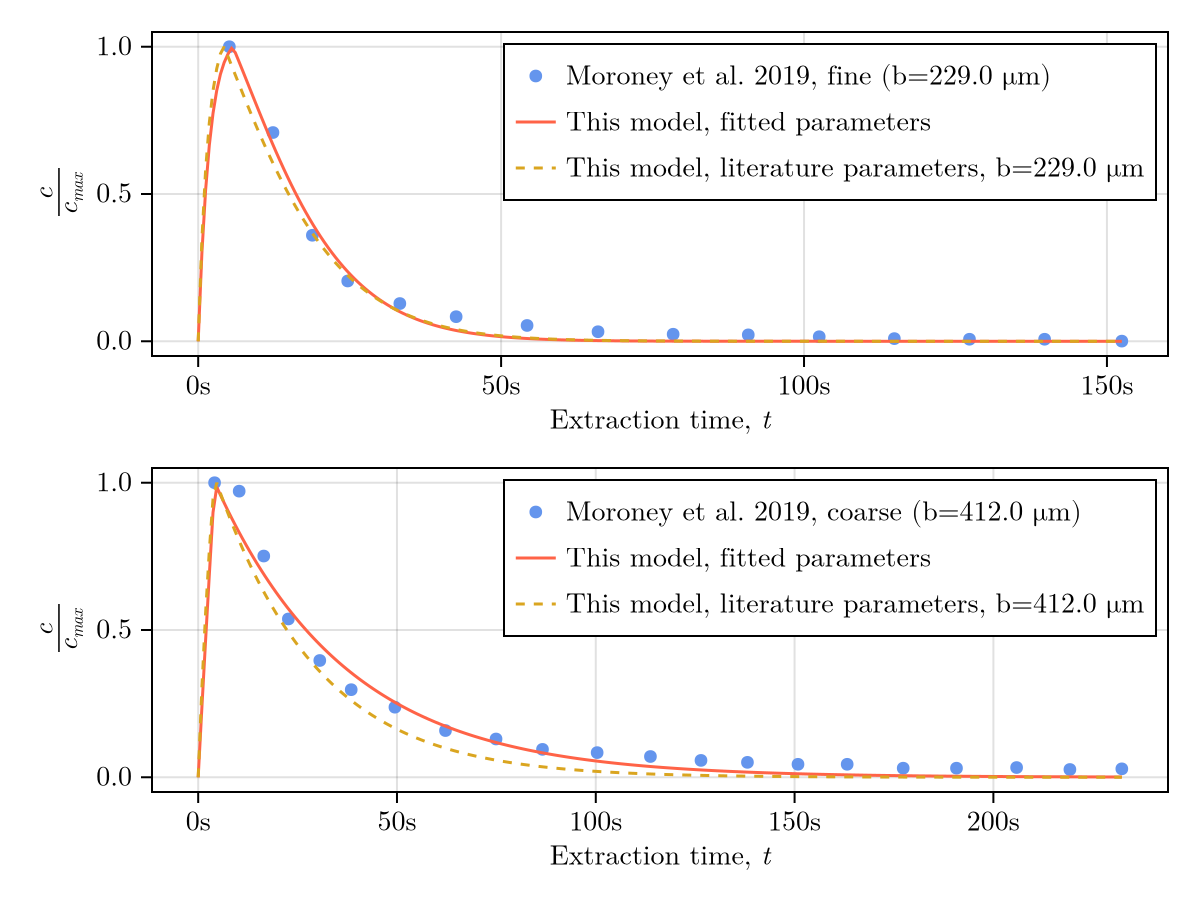

In [31]:
#| echo: false
#| label: fig-exp-plot-1
#| fig-cap: "Experimental data from Moroney et al. 2019, with two curves: the model developed here with best-fit parameters, the model developed here with the literature values provided here but particle diameters from Moroney 2019"

let df1 = moroney_2019_a, df2 = moroney_2019_c

@inline function plot_fit(fit, ts)
    τ₀, ξ, κ = Optim.minimizer(fit)
    u_max = u(ξ, ξ/κ; κ=κ, u₁=0, υ₁=1)
    τ₀ = τ₀*1u"s^-1"
    return [u(ξ, τ₀*t; κ=κ, u₁=0, υ₁=1)/u_max for t in ts]
end

@inline inits(ext) = [ ustrip(u"s^-1",ext.h*ext.a/ext.K),
                      (ext.pb.m*ext.h*ext.a*ext.pb.L)/ext.v,
                       ext.K*ext.pb.m ]
pb1  = PackedBed(
                    ε = 1 - 0.8272,
                    b = 457.82u"μm"/2,
                    R = 29.2u"mm",
                    L = 18.7u"mm",
                    q = q_sat,
                    D = 𝒟ₛ
                    )
ext1 = EspressoExtract(pb1,shot)
fit1 = fit_normalized_concentration(df1,inits(ext1))

pb2  = PackedBed(
            ε = 1 - 0.8272,
            b = 823.02u"μm"/2,
            R = 29.2u"mm",
            L = 18.7u"mm",
            q = q_sat,
            D = 𝒟ₛ
            )
ext2 = EspressoExtract(pb2,shot)
fit2 = fit_normalized_concentration(df2,inits(ext2))

with_theme(post_theme) do

f = Figure()

ax1 = Axis(f[1, 1],
    xlabel = L"Extraction time, $t$",
    dim1_conversion = Makie.UnitfulConversion(u"s"),
    ylabel = L"$\frac{c}{c_{max}}$",
    #dim2_conversion = Makie.UnitfulConversion(u"g/L")
)

ts1 = LinRange(0,maximum(df1.time),250).*1u"s"
scatter!(ax1, df1.time .* 1u"s", df1.normalized_c,
         label="Moroney et al. 2019, fine (b=$(round(u"μm",ext1.pb.b)))",
         color=:cornflowerblue)
lines!(ax1, ts1, plot_fit(fit1,ts1), 
       color=:tomato, linestyle=:solid,
       label="This model, fitted parameters")

cs1 = [ concentration(ext1,ext1.pb.L,t) for t in ts1 ]
lines!(ax1, ts1, cs1./maximum(cs1),
       color=:goldenrod,
       linestyle=:dash,
       label="This model, literature parameters, b=$(round(u"μm",ext1.pb.b))")

axislegend(position = :rt)

ax2 = Axis(f[2, 1],
    xlabel = L"Extraction time, $t$",
    dim1_conversion = Makie.UnitfulConversion(u"s"),
    ylabel = L"$\frac{c}{c_{max}}$",
    #dim2_conversion = Makie.UnitfulConversion(u"g/L")
)

ts2 = LinRange(0,maximum(df2.time),250).*1u"s"
scatter!(ax2, df2.time .* 1u"s", df2.normalized_c,
         label="Moroney et al. 2019, coarse (b=$(round(u"μm",ext2.pb.b)))",
         color=:cornflowerblue)
lines!(ax2, ts2, plot_fit(fit2,ts2), 
       color=:tomato, linestyle=:solid,
       label="This model, fitted parameters")  

cs2 = [ concentration(ext2,ext2.pb.L,t) for t in ts2 ]
lines!(ax2, ts2, cs2./maximum(cs2),
       color=:goldenrod,
       linestyle=:dash,
       label="This model, literature parameters, b=$(round(u"μm",ext2.pb.b))")

axislegend(position = :rt)


f

end

end

The least-squares fits of the concentration profile, [@fig-exp-plot-1], are not bad. They look superficially to have a similar level of skill as the simple 1D models presented in @moroney-2019. Which is suggestive that a simple model like this one could be a useful tool for analyzing espresso, in particular it gives one a convenient avenue for research: Finding better curves for the mass transfer coefficient (e.g. better correlations for the Sherwood number) and solid phase diffusion, and mapping out how those two parameters are impacted by differences in beans, grind, etc. This is a simpler exercise than trying to optimize the full model.

## Future Opportunities

Many of the more computationally intensive models in the literature include a bed with multiple particle sizes. I chose to ignore it for this particular case, but I think one could easily modify the system to have multiple solid phases, each with a different solid phase concentration $\bar{q}_i$.  The problem should still be solvable using Laplace transforms, but I haven't looked at it in depth (and those are famous last words). I think a more interesting case would be to re-work the @rasmuson-1980 model for a packed bed with solid phase diffusion and axial diffusion to have a different set of initial conditions. This would be more involved since inverting the Laplace transform would involve the Bromwich integral, which is nobody's idea of a good time. That would also motivate one to come up with a more robust integration method for the oscillating integral that comes out of that.

In this approach I chose to model the extraction after the pre-infusion step, with the initial conditions in the bed as a shaky initial guess. @grudeva-2026 have built a model for an espresso system that includes the bed starting with air in the pores, and models the hot water moving through the bed and initiating the extraction (the pre-infusion). The dynamics of hot water moving through the bed during the pre-infusion phase has been explored by putting an espresso maker in an X-ray machine(!)[@foster-2025], and it is suitably plug-like. I think an interesting extension to the model I explored here would be to investigate simpler models of the kind of moving front given in @grudeva-2026. Can one come up with a simple Anzelius-like expression that captures this phenomenon? At first blush I don't think so, at least not using the Laplace transform approach I used above without some serious modifications.

Another thing I have been thinking about is extending these models to a pour-over situation. I may come back to this later but flow through a conical packed bed, with a constant flowrate, works out to being the same as the cylindrical one when one makes the obvious change of variables^[instead of $\xi$ chose a new dimensionless distance $\eta = \int_0^\xi \frac{v_0}{v} d\eta$ where $\frac{v}{v_0}$ is the ratio of the velocity at point $z$ over the velocity at $z=0$ which comes from conservation of mass, the result is the same function of $u$ given above but with $\eta$ in place of $\xi$]. But a conventional pour-over does not have a constant flowrate, it is a function of the height of liquid above the bed of grounds (the square root of the height actually). A productive approximation could perhaps be generated as a perturbation. Either way it is worth thinking about, though I imagine very hard to test -- one thing espresso has in it's favour is ease of control of the brew parameters.

## References
::: {#refs}
:::